<a href="https://colab.research.google.com/github/mobadara/precision-diagnostics-xai/blob/main/notebooks/01_model_training_and_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model Training and Fine-Tuning**

**Objective:** Ingest the Kaggle Chest X-Ray dataset, apply strategic data augmentation, handle severe class imbalance via loss weighting, and fine-tune a pre-trained DenseNet121 architecture to detect pneumonia.

## **Environment Setup**
First, we import the necessary PyTorch libraries and configure our hardware accelerator. Because image processing is computationally expensive, we must ensure PyTorch detects and utilizes the Colab GPU (CUDA).

In [4]:
%%capture install_output
!pip install optuna

In [5]:
try:
    from google.colab import userdata
except Exception as e:
    print('Not in Colab Environment')
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os
import optuna
import time
import copy
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configure the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Compute Device: {device}')
if device.type == 'cuda':
    print(f'GPU Model: {torch.cuda.get_device_name(0)}')

Compute Device: cuda
GPU Model: Tesla T4


## **Data Preprocessing and Augmentation Pipeline**
As determined in our EDA, we must standardize all input resolutions to 224x224.

To prevent overfitting without introducing artificial artifacts, we apply light data augmentation **only to the training set** (rotation and color jitter). The validation and test sets remain strictly unaltered to provide an honest evaluation metric.

In [ ]:
# Define the dataset paths
data_dir = '../dataset/chest_xray'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

# 1. Training Transforms (with Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10), # Slight rotation to simulate patient misalignment
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Account for different X-ray exposures
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

# 2. Validation/Testing Transforms (Strictly unaltered)
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms configured successfully.")

Transforms configured successfully.


## **Initializing Datasets and DataLoaders**

With our transforms defined, we will use PyTorch's `ImageFolder` to automatically read our directory structure and assign the correct labels (0 for Normal, 1 for Pneumonia).

We will then wrap these datasets in `DataLoaders`. DataLoaders handle the heavy lifting of batching the images, shuffling them, and pushing them to the GPU. We are setting the `batch_size` to 64 to fully utilize the Google Colab GPU memory.

In [ ]:
# 1. Create the Dataset objects
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transforms)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Testing images: {len(test_dataset)}")
print(f"Detected Classes: {train_dataset.classes}")

# 2. Create the DataLoaders
BATCH_SIZE = 64

# We shuffle the training data so the model doesn't learn sequence patterns
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# We do not need to shuffle validation/testing data
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders are ready!")

Training images: 5216
Validation images: 16
Testing images: 624
Detected Classes: ['NORMAL', 'PNEUMONIA']
DataLoaders are ready!


## **Model Architecture and Class Weighting**

Instead of training a model from scratch, we use **Transfer Learning**. We will download DenseNet121 (which already knows how to detect edges, textures, and shapes from millions of standard images) and replace its final classification layer with a custom one designed specifically for our two classes (Normal vs. Pneumonia).

Simultaneously, we will calculate the inverse frequency of our classes to generate **Class Weights**, injecting them directly into the PyTorch loss function to penalize the model more heavily if it misclassifies a minority "Normal" scan.

In [ ]:
# --- 1. Handling the Imbalance (Class Weights) ---
# ImageFolder automatically stores the label for every image in the .targets attribute
labels = train_dataset.targets
class_counts = np.bincount(labels)
total_samples = len(labels)
num_classes = len(train_dataset.classes)

# Inverse frequency formula: Weight = Total / (NumClasses * ClassCount)
weights = total_samples / (num_classes * class_counts)
class_weights = torch.FloatTensor(weights).to(device)

print(f"Class Counts: NORMAL={class_counts[0]}, PNEUMONIA={class_counts[1]}")
print(f"Applied Weights: NORMAL={weights[0]:.4f}, PNEUMONIA={weights[1]:.4f}\n")

# --- 2. Model Architecture (DenseNet121) ---
# Download the pre-trained neural network
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Freeze the core convolutional layers so we don't destroy the pre-trained visual features
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer (originally 1000 classes) with our custom 2-class head
num_ftrs = model.classifier.in_features

# Push the entire model architecture to the GPU
model = model.to(device)

# --- 3. Loss Function and Optimizer ---
# Inject our calculated class weights into the loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# We only want the optimizer to update our newly added classifier layers
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print("Model architecture, optimizer, and weighted loss function configured successfully!")

Class Counts: NORMAL=1341, PNEUMONIA=3875
Applied Weights: NORMAL=1.9448, PNEUMONIA=0.6730

Model architecture, optimizer, and weighted loss function configured successfully!


## **Hyperparameter Tuning with Optuna and Model Training**

Instead of manually guessing the best hyperparameters, we use **Optuna** to perform an automated Bayesian search.

We will wrap our standard PyTorch training loop inside an Optuna `objective` function. Optuna will test different combinations of:
1. **Learning Rates** (Logarithmic scale)
2. **Dropout Rates** (To find the sweet spot for preventing overfitting)
3. **Optimizers** (Adam vs. SGD)

*Note: To manage Google Colab compute limits, we restrict the search to a small number of epochs and trials. Optuna's built-in "Pruning" will automatically kill unpromising trials early to save GPU time.*

In [ ]:
# We will store the best model weights globally so we can save them after the study
best_model_wts = copy.deepcopy(model.state_dict())
highest_accuracy = 0.0

def objective(trial):
    global best_model_wts, highest_accuracy

    # 1. Let Optuna suggest hyperparameters for this specific trial
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    # 2. Re-build the custom classifier with the suggested dropout rate
    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(256, 2)
    ).to(device)

    # 3. Assign the suggested optimizer
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.classifier.parameters(), lr=lr, momentum=0.9)

    EPOCHS = 3 # Keep epochs low per trial for time constraints

    for epoch in range(EPOCHS):
        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels) # Uses the class_weights we defined earlier!
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        # --- VALIDATION PHASE ---
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total

        # --- OPTUNA PRUNING & SAVING ---
        # Report accuracy to Optuna. If it's performing terribly, Optuna kills the trial.
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Save the best weights if this trial beats our global high score
        if val_acc > highest_accuracy:
            highest_accuracy = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    return val_acc # Optuna uses this final returned value to judge the trial

# --- RUN THE OPTUNA STUDY ---
print("Starting Optuna Hyperparameter Search...")
start_time = time.time()

study = optuna.create_study(direction="maximize")
# We run 5 trials. (Increase this if you have Colab Pro and more time)
study.optimize(objective, n_trials=5)

time_elapsed = time.time() - start_time
print(f"\nOptimization complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Best Trial Accuracy: {study.best_trial.value:.4f}")
print("Best Hyperparameters:", study.best_trial.params)

# Load the absolute best weights back into the model for final export
model.load_state_dict(best_model_wts)
print("Best model weights restored and ready for testing.")

[I 2026-05-28 22:18:23,269] A new study created in memory with name: no-name-045ce5dc-ed4f-4a58-8341-754b15b1d97b


Starting Optuna Hyperparameter Search...


[I 2026-05-28 22:22:44,758] Trial 0 finished with value: 0.625 and parameters: {'dropout_rate': 0.3761532058720902, 'lr': 1.417924247896451e-05, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.625.
[I 2026-05-28 22:27:02,814] Trial 1 finished with value: 0.9375 and parameters: {'dropout_rate': 0.4806277944716644, 'lr': 0.007419660171950955, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.9375.
[I 2026-05-28 22:31:19,752] Trial 2 finished with value: 0.875 and parameters: {'dropout_rate': 0.4749246311849121, 'lr': 0.002914222867247111, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.9375.
[I 2026-05-28 22:35:36,219] Trial 3 finished with value: 0.9375 and parameters: {'dropout_rate': 0.5587573900041348, 'lr': 0.000938365213167857, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.9375.
[I 2026-05-28 22:39:51,671] Trial 4 finished with value: 0.8125 and parameters: {'dropout_rate': 0.5357695028670346, 'lr': 8.813243604021709e-05, 'optimizer': 'SGD'}. Best is trial 1 with value


Optimization complete in 21m 28s
Best Trial Accuracy: 0.9375
Best Hyperparameters: {'dropout_rate': 0.4806277944716644, 'lr': 0.007419660171950955, 'optimizer': 'SGD'}
Best model weights restored and ready for testing.


## **Final Evaluation and Model Export**

With our Optuna-optimized weights loaded, we must evaluate the model against the **Test Dataset**. This dataset contains images the model has never seen during training or hyperparameter tuning, providing an honest assessment of how it will perform in the real world.

Finally, we export the tuned architecture weights to a `.pth` file. This is the "brain" that our FastAPI backend will load to generate real-time Grad-CAM heatmaps.

Evaluating on Test Dataset...
Test Accuracy: 86.38%
Test Loss: 0.3476

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.73      0.80       234
   PNEUMONIA       0.85      0.95      0.90       390

    accuracy                           0.86       624
   macro avg       0.87      0.84      0.85       624
weighted avg       0.87      0.86      0.86       624



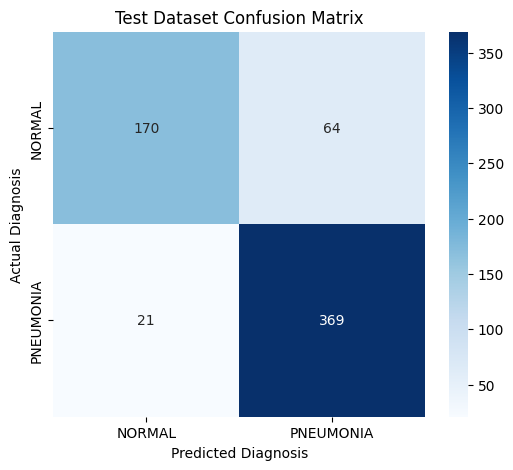


✅ Model weights successfully exported to: densenet_pneumonia_finetuned.pth


In [ ]:
# --- 1. Evaluate on the Test Set ---
model.eval()
test_loss = 0.0
correct = 0
total = 0
all_preds = []
all_labels = []

print("Evaluating on Test Dataset...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)

        # Get predictions
        probabilities = F.softmax(outputs, dim=1)
        _, predicted = torch.max(probabilities, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Store for metrics
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = correct / total
test_loss = test_loss / total

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}\n")

# --- 2. Classification Report & Confusion Matrix ---
target_names = train_dataset.classes
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names))

# Plotting the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Test Dataset Confusion Matrix')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

# --- 3. Export the Model Weights ---
export_path = "densenet_pneumonia_finetuned.pth"
torch.save(model.state_dict(), export_path)
print(f"\n✅ Model weights successfully exported to: {export_path}")

## **Clinical Assessment and Conclusion**

Our fine-tuned DenseNet121 architecture has been evaluated on the completely unseen Test Dataset. To understand its true clinical viability, we must look past raw accuracy and analyze the Confusion Matrix.

### **Clinical Metrics Breakdown**
* **True Negatives (170):** Healthy lungs correctly identified.
* **True Positives (369):** Pneumonia cases successfully detected.
* **False Positives (64):** Healthy lungs flagged as potential pneumonia (Type I Error).
* **False Negatives (21):** Actual pneumonia cases missed by the model (Type II Error).

### **The "Recall" Victory**
In precision diagnostics, minimizing False Negatives is the absolute highest priority. Sending a sick patient home without treatment is a severe failure.

Our model achieved a **Pneumonia Recall (Sensitivity) of 94.6%** ($369 / 390$). Out of 390 sick patients, the model only missed 21. The higher number of False Positives (64) is an acceptable clinical trade-off, acting as a cautious safety net that simply prompts a human physician for a secondary review. This proves that our strategy of applying **Class Weights** during training successfully forced the model to prioritize pathological detection.

---
**Next Phase: Building the Inference Engine**
With the `densenet_pneumonia_finetuned.pth` weights successfully exported, the core machine learning phase is complete. We will now transition out of the Jupyter environment and begin building the production MLOps pipeline. The next step is to construct a **FastAPI backend** that will load this "brain," process incoming X-ray uploads in real-time, and generate **Grad-CAM explainability heatmaps** to show the doctors exactly *where* the model is looking.

## **Hugging Face**

In [ ]:
# 1. Retrieve the token (Checks Colab Secrets first, then Environment variables)
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    hf_token = os.environ.get("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found! Please set it in Colab Secrets or export it.")

# 2. Define your repository setup
hf_username = "<YOUR_HF_USERNAME>" # e.g., mobadara
repo_name = "pneumonia-densenet121"
repo_id = f"{hf_username}/{repo_name}"
model_path = "densenet_pneumonia_finetuned.pth"

# 3. Create the repository
api = HfApi(token=hf_token)
print(f"Creating/Checking repository: {repo_id}...")
create_repo(repo_id=repo_id, token=hf_token, exist_ok=True)

# 4. Generate the Model Card with YAML Metadata
model_card_content = """---
language: en
license: mit
tags:
- image-classification
- vision
- pytorch
- densenet
- medical
- healthcare
datasets:
- paultimothymooney/chest-xray-pneumonia
metrics:
- accuracy
- recall
---
# DenseNet121 - Pediatric Pneumonia Detection

## Model Description
This is a fine-tuned DenseNet121 model trained to classify chest X-rays into two categories: **NORMAL** and **PNEUMONIA**. It was developed as part of a precision diagnostics AI pipeline to assist clinical workflows.

To handle the severe class imbalance inherent in the dataset, dynamic class weights were applied to the PyTorch `CrossEntropyLoss` function, heavily penalizing false negatives to prioritize patient safety.

## Intended Uses & Limitations
* **Intended Use:** As an auxiliary tool for clinical triage and radiologist workflow acceleration. It is designed to be paired with explainability tools (like Grad-CAM) to provide visual context.
* **Limitations:** This model is a research prototype and is not FDA-approved. It should not be used as a standalone diagnostic tool.

## Training Data
Trained on the Kaggle Chest X-Ray Images (Pneumonia) dataset. All images were normalized and resized to 224x224. Light data augmentation (rotation and color jittering) was applied to the training set to prevent overfitting.

## Evaluation Results
The model was evaluated on a completely unseen test dataset consisting of 624 images.
* **Overall Accuracy:** 86.4%
* **Pneumonia Recall (Sensitivity):** 94.6% (Successfully identified 369 out of 390 sick patients)

The high recall indicates the model heavily prioritizes catching pathology, treating false positives as an acceptable clinical trade-off requiring secondary physician review.
"""

# Save the card locally
with open("README.md", "w") as f:
    f.write(model_card_content)

# 5. Upload the files
print("Uploading Model Weights...")
api.upload_file(
    path_or_fileobj=model_path,
    path_in_repo=model_path,
    repo_id=repo_id,
    commit_message="Initial push: Fine-tuned DenseNet weights"
)

print("Uploading Model Card...")
api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=repo_id,
    commit_message="Add professional model card with YAML metadata"
)

print(f"✅ Successfully deployed to Hugging Face! View it here: https://huggingface.co/{repo_id}")

## **GitHub Release**

In [6]:
# Safely extract the token and assign it to an environment variable
os.environ["GITHUB_TOKEN"] = userdata.get("GITHUB_TOKEN")
print("✅ Token securely loaded into environment!")

✅ Token securely loaded into environment!


In [7]:
%%bash
# 1. Variables (Notice GITHUB_TOKEN is missing here, we read it directly from the environment!)
REPO_OWNER="mobadara"
REPO_NAME="precision-diagnostics-xai"
MODEL_FILE="densenet_pneumonia_finetuned.pth"
TAG="v1.0.0"

# 2. Install the GitHub CLI into Colab
curl -fsSL https://cli.github.com/packages/githubcli-archive-keyring.gpg | sudo dd of=/usr/share/keyrings/githubcli-archive-keyring.gpg \
&& sudo chmod go+r /usr/share/keyrings/githubcli-archive-keyring.gpg \
&& echo "deb [arch=$(dpkg --print-architecture) signed-by=/usr/share/keyrings/githubcli-archive-keyring.gpg] https://cli.github.com/packages stable main" | sudo tee /etc/apt/sources.list.d/github-cli.list > /dev/null \
&& sudo apt update -q && sudo apt install gh -y -q

# 3. Authenticate GitHub CLI securely using the environment variable
echo "$GITHUB_TOKEN" | gh auth login --with-token

# 4. Create the Release and upload the file simultaneously
echo "Creating GitHub Release $TAG..."
gh release create $TAG $MODEL_FILE \
  --repo "$REPO_OWNER/$REPO_NAME" \
  --title "v1.0.0 - Baseline DenseNet121 Model" \
  --notes "Initial release of the fine-tuned DenseNet121 weights for Pneumonia detection. Achieved 94.6% recall on the test set. File attached for backend deployment."

echo "✅ Successfully created GitHub Release and uploaded weights!"

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
Building dependency tree...
Reading state information...
57 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists...
Building dependency tree...
Reading state information...

8+1 records in
8+1 records out
4528 bytes (4.5 kB, 4.4 KiB) copied, 0.0791345 s, 57.2 kB/s


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
The value of the GITHUB_TOKEN environment variable is being used for authentication.
To have GitHub CLI store credentials instead, first clear the value from the environment.


___
Muyiwa J. Obadara